# CUSTOMER CHURN AND RETENTION ANALYSIS

## 1. Problem Statement

Customer churn can negatively affect revenue and long-term customer retention. The objective is to explore customer data and identify patterns and characteristics associated with churn, particularly across tenure, charges, contracts, and customer value.

## 2. Objective

To perform exploratory data analysis using Python to visualize churn patterns, understand relationships between important customer variables, and identify potential high-risk customer groups.

### 3. Import Libraries 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print('Done')

Done


### 4. Load Dataset

In [2]:
import pandas as pd
Cutomer_account = pd.read_csv(r"C:\Users\Simran\Downloads\customer_account.csv")
Cutomer_churn = pd.read_csv(r"C:\Users\Simran\Downloads\customer_churn.csv")
dim_customer = pd.read_csv(r"C:\Users\Simran\Downloads\dim_customer.csv")
dim_service = pd.read_csv(r"C:\Users\Simran\Downloads\dim_services.csv")
print("done")

done


In [3]:
print("Customer_account" in globals())
print("customer_account" in globals())
print("customer_churn" in globals())

False
False
False


In [4]:
customer_account = pd.read_csv(r"C:\Users\Simran\Downloads\customer_account.csv")
customer_churn = pd.read_csv(r"C:\Users\Simran\Downloads\customer_churn.csv")
dim_customer = pd.read_csv(r"C:\Users\Simran\Downloads\dim_customer.csv")
dim_services = pd.read_csv(r"C:\Users\Simran\Downloads\dim_services.csv")

print('Done')

Done


In [5]:
print(customer_account.shape)
print(customer_churn.shape)
print(dim_customer.shape)
print(dim_services.shape)

(7043, 9)
(7043, 5)
(7043, 8)
(7043, 10)


In [6]:
customer_account.head()

,customerID,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,MonthlyChargeBand,TotalCharges,CustomerValue,IsMonthToMonth
0,7590-VHVEG,Month-to-month,Yes,Electronic check,29.85,Low,29.85,Low Value,Yes
1,5575-GNVDE,One year,No,Mailed check,56.95,Medium,1889.50,Medium Value,No
2,3668-QPYBK,Month-to-month,Yes,Mailed check,53.85,Medium,108.15,Low Value,Yes
3,7795-CFOCW,One year,No,Bank transfer (automatic),42.30,Medium,1840.75,Medium Value,No
4,9237-HQITU,Month-to-month,Yes,Electronic check,70.70,High,151.65,Low Value,Yes


In [7]:
customer_churn.head()

,customerID,Churn,CustomerStatus,ChurnFlag,RetentionPriority
0,7590-VHVEG,No,Retained,0,Priority 5 - Other Retained
1,5575-GNVDE,No,Retained,0,Priority 5 - Other Retained
2,3668-QPYBK,Yes,Churned,1,Priority 3 - Low Value Churned
3,7795-CFOCW,No,Retained,0,Priority 5 - Other Retained
4,9237-HQITU,Yes,Churned,1,Priority 3 - Low Value Churned


In [8]:
dim_customer.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,TenureGroup,IsNewCustomer
0,7590-VHVEG,Female,0,Yes,No,1,0-6 Months,Yes
1,5575-GNVDE,Male,0,No,No,34,25-48 Months,No
2,3668-QPYBK,Male,0,No,No,2,0-6 Months,Yes
3,7795-CFOCW,Male,0,No,No,45,25-48 Months,No
4,9237-HQITU,Female,0,No,No,2,0-6 Months,Yes


In [9]:
dim_services.head()

,customerID,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,No,No phone service,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,Yes,No,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,Yes,No,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,No,No phone service,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Yes,No,Fiber optic,No,No,No,No,No,No


### 5. Data Understanding

#### 5.1 Basic Information

In [10]:
customer_account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7043 non-null   object 
 1   Contract           7043 non-null   object 
 2   PaperlessBilling   7043 non-null   object 
 3   PaymentMethod      7043 non-null   object 
 4   MonthlyCharges     7043 non-null   float64
 5   MonthlyChargeBand  7043 non-null   object 
 6   TotalCharges       7032 non-null   float64
 7   CustomerValue      7032 non-null   object 
 8   IsMonthToMonth     7043 non-null   object 
dtypes: float64(2), object(7)
memory usage: 495.3+ KB


In [11]:
dim_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
 5   tenure         7043 non-null   int64 
 6   TenureGroup    7043 non-null   object
 7   IsNewCustomer  7043 non-null   object
dtypes: int64(2), object(6)
memory usage: 440.3+ KB


In [12]:
dim_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
 5   tenure         7043 non-null   int64 
 6   TenureGroup    7043 non-null   object
 7   IsNewCustomer  7043 non-null   object
dtypes: int64(2), object(6)
memory usage: 440.3+ KB


In [13]:
dim_services.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7043 non-null   object
 1   PhoneService      7043 non-null   object
 2   MultipleLines     7043 non-null   object
 3   InternetService   7043 non-null   object
 4   OnlineSecurity    7043 non-null   object
 5   OnlineBackup      7043 non-null   object
 6   DeviceProtection  7043 non-null   object
 7   TechSupport       7043 non-null   object
 8   StreamingTV       7043 non-null   object
 9   StreamingMovies   7043 non-null   object
dtypes: object(10)
memory usage: 550.4+ KB


#### 5.2 Check Missing Value

In [14]:
customer_account.isnull().sum()


customerID            0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
MonthlyChargeBand     0
TotalCharges         11
CustomerValue        11
IsMonthToMonth        0
dtype: int64

In [15]:
customer_account.dtypes

customerID            object
Contract              object
PaperlessBilling      object
PaymentMethod         object
MonthlyCharges       float64
MonthlyChargeBand     object
TotalCharges         float64
CustomerValue         object
IsMonthToMonth        object
dtype: object

##### 5.2.1 Handling missing value

In [16]:
customer_account[customer_account['TotalCharges'].isnull()]


,customerID,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,MonthlyChargeBand,TotalCharges,CustomerValue,IsMonthToMonth
488,4472-LVYGI,Two year,Yes,Bank transfer (automatic),52.55,Medium,NaN,NaN,No
753,3115-CZMZD,Two year,No,Mailed check,20.25,Low,NaN,NaN,No
936,5709-LVOEQ,Two year,No,Mailed check,80.85,High,NaN,NaN,No
1082,4367-NUYAO,Two year,No,Mailed check,25.75,Low,NaN,NaN,No
1340,1371-DWPAZ,Two year,No,Credit card (automatic),56.05,Medium,NaN,NaN,No
3331,7644-OMVMY,Two year,No,Mailed check,19.85,Low,NaN,NaN,No
3826,3213-VVOLG,Two year,No,Mailed check,25.35,Low,NaN,NaN,No
4380,2520-SGTTA,Two year,No,Mailed check,20.00,Low,NaN,NaN,No
5218,2923-ARZLG,One year,Yes,Mailed check,19.70,Low,NaN,NaN,No
6670,4075-WKNIU,Two year,No,Mailed check,73.35,High,NaN,NaN,No


In [17]:
customer_account.dropna(subset=['TotalCharges', 'CustomerValue'], inplace=True)
print('Done')

Done


In [18]:
customer_account.isnull().sum()

customerID           0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
MonthlyChargeBand    0
TotalCharges         0
CustomerValue        0
IsMonthToMonth       0
dtype: int64

In [19]:
customer_account.isnull().sum()

customerID           0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
MonthlyChargeBand    0
TotalCharges         0
CustomerValue        0
IsMonthToMonth       0
dtype: int64

In [20]:
customer_churn.isnull().sum()


customerID           0
Churn                0
CustomerStatus       0
ChurnFlag            0
RetentionPriority    0
dtype: int64

In [21]:
dim_customer.isnull().sum()

customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
tenure           0
TenureGroup      0
IsNewCustomer    0
dtype: int64

In [22]:
dim_services.isnull().sum()

customerID          0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

#### 5.3 Check Duplicates

In [23]:
customer_account.duplicated().sum()

np.int64(0)

In [24]:
customer_account.duplicated().sum()

np.int64(0)

In [25]:
dim_customer.duplicated().sum()

np.int64(0)

In [26]:
dim_services.duplicated().sum()

np.int64(0)

### 6. CREATE ONE ANALYSIS DATAFRAME

In [27]:
df = (
    customer_churn
    .merge(dim_customer, on="customerID", how="left")
    .merge(customer_account, on="customerID", how="left")
    .merge(dim_services, on="customerID", how="left")
)
print('Done')

Done


In [28]:
df.head()

,customerID,Churn,CustomerStatus,ChurnFlag,RetentionPriority,gender,SeniorCitizen,Partner,Dependents,tenure,...,IsMonthToMonth,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,No,Retained,0,Priority 5 - Other Retained,Female,0,Yes,No,1,...,Yes,No,No phone service,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,No,Retained,0,Priority 5 - Other Retained,Male,0,No,No,34,...,No,Yes,No,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,Yes,Churned,1,Priority 3 - Low Value Churned,Male,0,No,No,2,...,Yes,Yes,No,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,No,Retained,0,Priority 5 - Other Retained,Male,0,No,No,45,...,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Yes,Churned,1,Priority 3 - Low Value Churned,Female,0,No,No,2,...,Yes,Yes,No,Fiber optic,No,No,No,No,No,No


In [29]:
df.shape

(7043, 29)

### 7. CHURN DISTRIBUTION

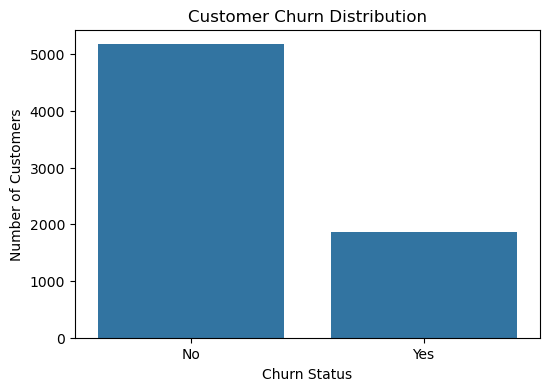

In [30]:
# What does overall churnrate look like??

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

#### 7.1 Churn VS Tenure 

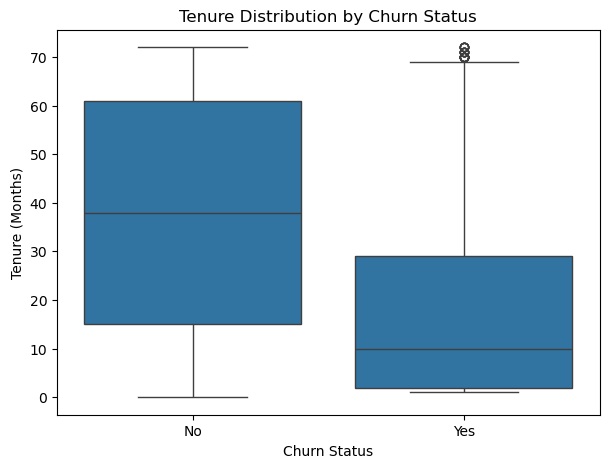

In [31]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.show()

#### 7.2 CHURN VS MONTHLY CHARGES

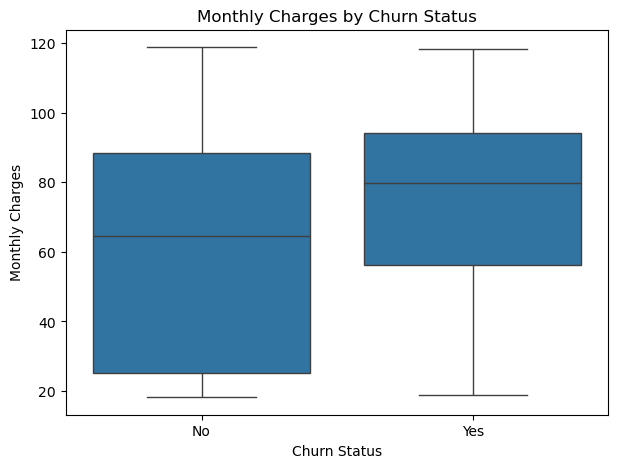

In [32]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.show()

#### 7.3 CHURN VS CONTRACT 

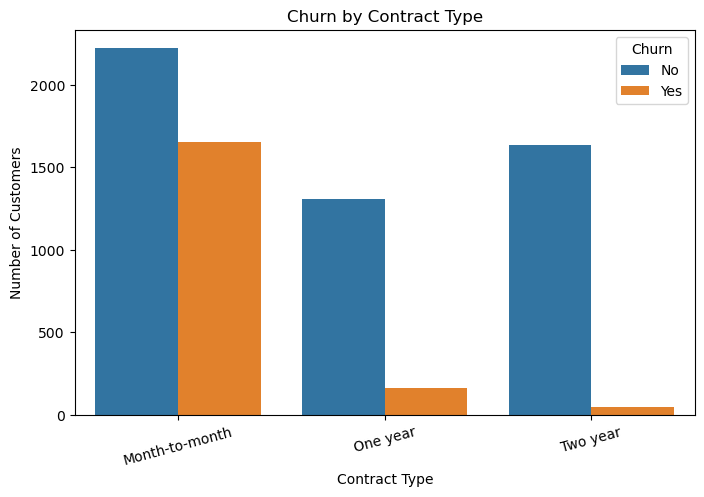

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

#### 7.4 CHURN VS CUSTOMER SEGMENT

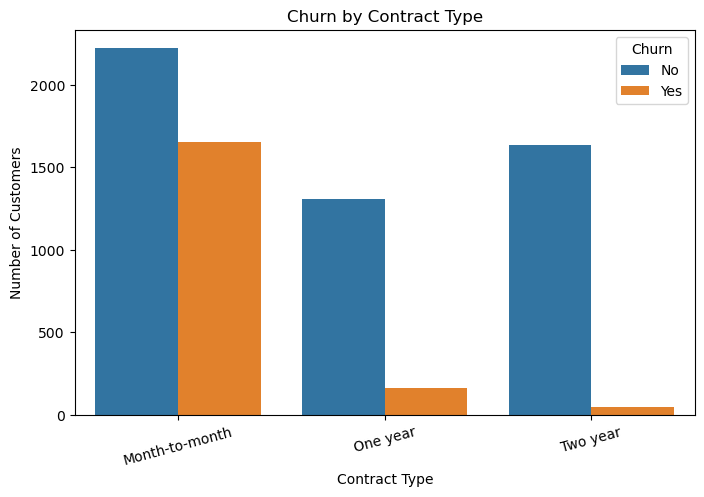

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

#### 7.5 HIGH-VALUE CHURNED CUSTOMERS  

In [35]:
high_value_churned = df[
    (df["CustomerValue"] == "High Value") &
    (df["Churn"] == "Yes")
]

high_value_churned.head()

,customerID,Churn,CustomerStatus,ChurnFlag,RetentionPriority,gender,SeniorCitizen,Partner,Dependents,tenure,...,IsMonthToMonth,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
8,7892-POOKP,Yes,Churned,1,Priority 1 - High Value Churned,Female,0,Yes,No,28,...,Yes,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes
13,0280-XJGEX,Yes,Churned,1,Priority 1 - High Value Churned,Male,0,No,No,49,...,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes
26,6467-CHFZW,Yes,Churned,1,Priority 1 - High Value Churned,Male,0,Yes,Yes,47,...,Yes,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes
38,5380-WJKOV,Yes,Churned,1,Priority 1 - High Value Churned,Male,0,No,No,34,...,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes
104,3192-NQECA,Yes,Churned,1,Priority 1 - High Value Churned,Male,0,Yes,No,68,...,No,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes


In [36]:
print("High-value churned customers:",
      len(high_value_churned))

High-value churned customers: 387


#### 7.6 HIGH-VALUE CHURNED REVENUE 

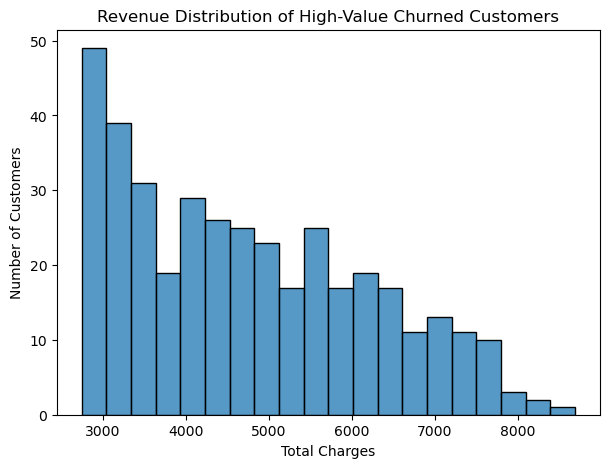

In [37]:
## QUES. How much historical revenue is associated with high-value customers who churned?

plt.figure(figsize=(7,5))

sns.histplot(
    data=high_value_churned,
    x="TotalCharges",
    bins=20
)

plt.title("Revenue Distribution of High-Value Churned Customers")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

#### 7.7  Short-Tenure + High-Charge Customers

In [38]:
# step 1 First calculate average monthly charge:
avg_monthly_charge = df["MonthlyCharges"].mean()

print("Average Monthly Charges:",
      round(avg_monthly_charge, 2))

Average Monthly Charges: 64.8


In [39]:
# step 2 Now identify potential risk customers:
early_high_charge = df[
    (df["tenure"] <= 12) &
    (df["MonthlyCharges"] > avg_monthly_charge)
]
print('done')

done


In [40]:
# step 3 check
early_high_charge.head()

,customerID,Churn,CustomerStatus,ChurnFlag,RetentionPriority,gender,SeniorCitizen,Partner,Dependents,tenure,...,IsMonthToMonth,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
4,9237-HQITU,Yes,Churned,1,Priority 3 - Low Value Churned,Female,0,No,No,2,...,Yes,Yes,No,Fiber optic,No,No,No,No,No,No
5,9305-CDSKC,Yes,Churned,1,Priority 2 - Medium Value Churned,Female,0,No,No,8,...,Yes,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes
31,4929-XIHVW,No,Retained,0,Priority 5 - Other Retained,Male,1,Yes,No,2,...,Yes,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes
36,6047-YHPVI,Yes,Churned,1,Priority 3 - Low Value Churned,Male,0,No,No,5,...,Yes,Yes,No,Fiber optic,No,No,No,No,No,No
39,8168-UQWWF,Yes,Churned,1,Priority 2 - Medium Value Churned,Female,0,No,No,11,...,Yes,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes


In [41]:
# step 4 count
print("Short-tenure & high-charge customers:",
      len(early_high_charge))

Short-tenure & high-charge customers: 1004


#### 7.8 TENURE VS MONTHLY CHARGES 

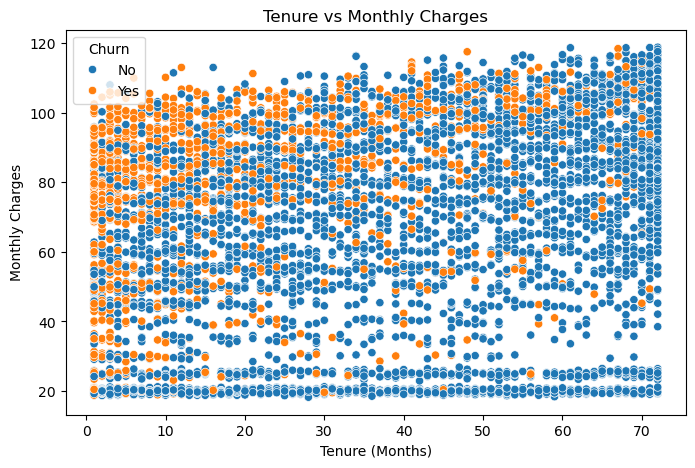

In [42]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("Tenure vs Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")

plt.show()

#### 7.9 Correlation Analysis 


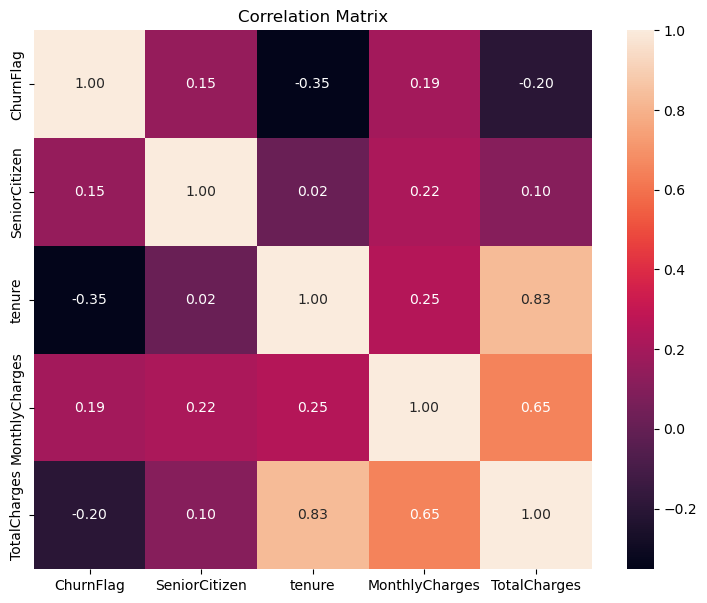

In [43]:
# step 1: select numerical columns
numeric_df = df.select_dtypes(include="number")

#step 2 : calculate correlation
correlation = numeric_df.corr()

# step 3 : create heatmap
plt.figure(figsize=(9,7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

#### 7.10 SERVICES ANALYSIS

<Figure size 900x700 with 0 Axes>

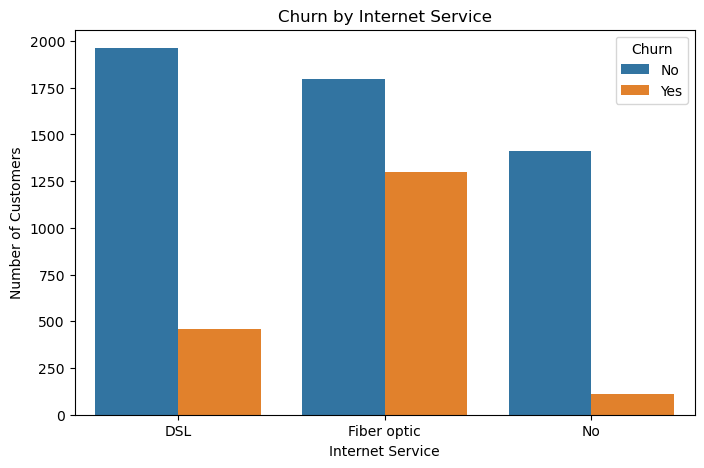

In [44]:
plt.figure(figsize=(9,7))

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### KEY FINDINGS
1. Churn and Retention: The EDA shows a considerable difference between churned and retained customers, making customer retention an important   b      business concern.
2. Tenure: Churned customers generally have lower tenure than retained customers, indicating that newer customers may require greater retention   a      attention.
3. Monthly Charges: Churned and retained customers show different monthly-charge distributions, making monthly charges an important variable to         consider when analyzing churn.
4. Contract Type: Month-to-month customers show a stronger churn pattern compared with customers on longer-term contracts.
5. Customer Segment: Low-value customers have the highest churn rate at 39.51%, followed by medium-value customers at 23.72%, while high-value          Customers have the lowest churn rate at 16.51%.
6. High-Value Churn: The analysis identified 387 high-value customers who have already churned, making this an important group for revenue and
   retention analysis.
8. Potential Risk Group: 1,004 customers have a tenure of 12 months or less and monthly charges above the overall average of 64.80, making them a  p    potential group for further retention investigation.
9. Service Analysis: Service-level analysis was performed to examine how churn patterns differ across internet/service categories.

### Conclusion

The Python EDA provided a visual understanding of customer churn patterns and highlighted important relationships between churn, tenure, monthly charges, contract type, customer value, and services. The analysis particularly identified newer customers, month-to-month customers, and high-value churned customers as important groups for retention analysis. These findings complement the SQL analysis and will be used to build the Power BI dashboard for interactive business analysis and decision-making. 